In [17]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler


pd.set_option('display.max_columns', None)

df = pd.read_csv('final_gold.csv')

df['time'] = pd.to_datetime(df['time'])
df['hora'] = df['time'].dt.hour
df['part_of_day'] = df['hora'].apply(lambda h: (
    0 if h < 6 else #Madrugada = 0
    3 if h < 12 else #Mañana = 3
    2 if h < 18 else  #Tarde = 2
    1 #Noche = 1
))

df['mes'] = df['time'].dt.month
df['season'] = df['hora'].apply(lambda h: (
    0 if h in [12,1,2] else #Invierno = 0
    1 if h in [3,4,5] else #Primavera = 1
    2 if h in [6,7,8] else #Verano = 2
    3 #Otoño = 3
))

df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 23)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 23)

df["dia_semana"] = df["time"].dt.dayofweek  # Día de la semana (0=lunes)
# Codificación one-hot para dia_semana (ahora solo contiene 0 a 4)
df = pd.get_dummies(df, columns=['dia_semana'], prefix='dia', drop_first=True)



X_df = df.drop(columns=["time","temperatura_calefaccion_y",'sensor.sensor_temperatura_2_humidity', 'sensor.sensor_temperatura_2_pressure', 'sensor.sensor_temperatura_2_temperature', 'sensor.sensor_temperatura_3_humidity', 'sensor.sensor_temperatura_3_pressure', 'sensor.sensor_temperatura_3_temperature'])
y_df = df["temperatura_calefaccion_y"]



# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

model = LinearRegression()  
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Resultados
print("R²:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

# probar tasas de aprendizaje, funciones activacion y num neuronas
df.to_csv('entrenamiento_neuronal_calefaccion.csv', index=False)

X_df


R²: 0.9228992506146165
MAE: 0.5258244571863165
MSE: 0.43403962779833866
RMSE: 0.658816839340297


,sensor.sensor_temperatura_1_humidity,sensor.sensor_temperatura_1_pressure,sensor.sensor_temperatura_1_temperature,sensor_puerta_1 Puerta,suma_ventanas_arriba,suma_ventanas_abajo,azimuth_mean,elevacion_sol,temperatura_exterior,porcentaje_nubes,hora,part_of_day,mes,season,hora_sin,hora_cos,dia_1,dia_2,dia_3,dia_4,dia_5,dia_6
0,46.30,1014.6,19.74,0.0,0.0,0.0,285.41,-53.48,12.5,100.0,21,1,12,3,-5.195840e-01,0.854419,True,False,False,False,False,False
1,45.78,1014.6,19.51,0.0,0.0,0.0,303.03,-64.02,12.0,100.0,22,1,12,3,-2.697968e-01,0.962917,True,False,False,False,False,False
2,45.45,1014.2,19.24,0.0,0.0,0.0,250.84,-72.16,11.4,100.0,23,1,12,3,-2.449294e-16,1.000000,True,False,False,False,False,False
3,45.30,1014.4,19.09,0.0,0.0,0.0,29.55,-71.20,11.2,39.0,0,0,12,3,0.000000e+00,1.000000,False,True,False,False,False,False
4,45.25,1014.4,18.86,0.0,0.0,0.0,59.16,-63.06,10.6,32.0,1,0,12,0,2.697968e-01,0.962917,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2492,47.17,1011.5,21.36,3600.0,0.0,0.0,273.44,-1.18,15.5,87.0,18,1,3,3,-9.790841e-01,0.203456,False,False,False,False,False,False
2493,47.73,1012.2,21.40,2366.0,0.0,0.0,283.89,-13.52,14.7,56.0,19,1,3,3,-8.878852e-01,0.460065,False,False,False,False,False,False
2494,48.80,1013.2,20.71,0.0,0.0,0.0,295.64,-25.12,13.5,33.0,20,1,3,3,-7.308360e-01,0.682553,False,False,False,False,False,False
2495,49.68,1013.5,20.17,0.0,0.0,0.0,308.84,-34.89,13.1,41.0,21,1,3,3,-5.195840e-01,0.854419,False,False,False,False,False,False


# Red neuronal

Epoch 1/100


/home/pablo/miniconda3/envs/tf-wsl-ia/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 15.3343 - val_loss: 2.2644
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6271 - val_loss: 1.2300
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0495 - val_loss: 0.9311
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8232 - val_loss: 0.8318
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6890 - val_loss: 1.1501
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6788 - val_loss: 0.6715
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5658 - val_loss: 0.6264
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5338 - val_loss: 0.5805
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5280 - val_loss: 0.6017
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4489 - val_loss: 0.6801
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5005 - val_loss: 0.6471
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5398 - val

/home/pablo/miniconda3/envs/tf-wsl-ia/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 13.9411 - val_loss: 1.0752
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ -1s -11546us/step - loss: 0.8166 - val_loss: 0.6493
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5696 - val_loss: 0.5813
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5041 - val_loss: 0.4695
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4426 - val_loss: 0.4555
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4189 - val_loss: 0.4386
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3973 - val_loss: 0.3963
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3839 - val_loss: 0.5313
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4023 - val_loss: 0.3616
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3810 - val_loss: 0.3820
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3622 - val_loss: 0.3628
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3586 

...

/home/pablo/miniconda3/envs/tf-wsl-ia/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 8.6083 - val_loss: 1.8088
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2860 - val_loss: 1.2683
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0752 - val_loss: 1.1134
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8683 - val_loss: 1.4942
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9922 - val_loss: 1.3702
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8441 - val_loss: 1.8860
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1851 - val_loss: 0.9101
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7261 - val_loss: 1.1690
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8671 - val_loss: 0.6302
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6812 - val_loss: 0.6079
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7044 - val_loss: 0.5538
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7067 - val_l

/home/pablo/miniconda3/envs/tf-wsl-ia/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 7.4197 - val_loss: 0.5845
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5851 - val_loss: 0.6121
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5582 - val_loss: 0.5040
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4822 - val_loss: 0.6043
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5083 - val_loss: 0.4654
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4260 - val_loss: 0.5136
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4634 - val_loss: 0.3780
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4208 - val_loss: 0.4837
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4239 - val_loss: 0.4084
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3643 - val_loss: 0.4046
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3850 - val_loss: 0.3303
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3295 - val_l

KeyboardInterrupt: 

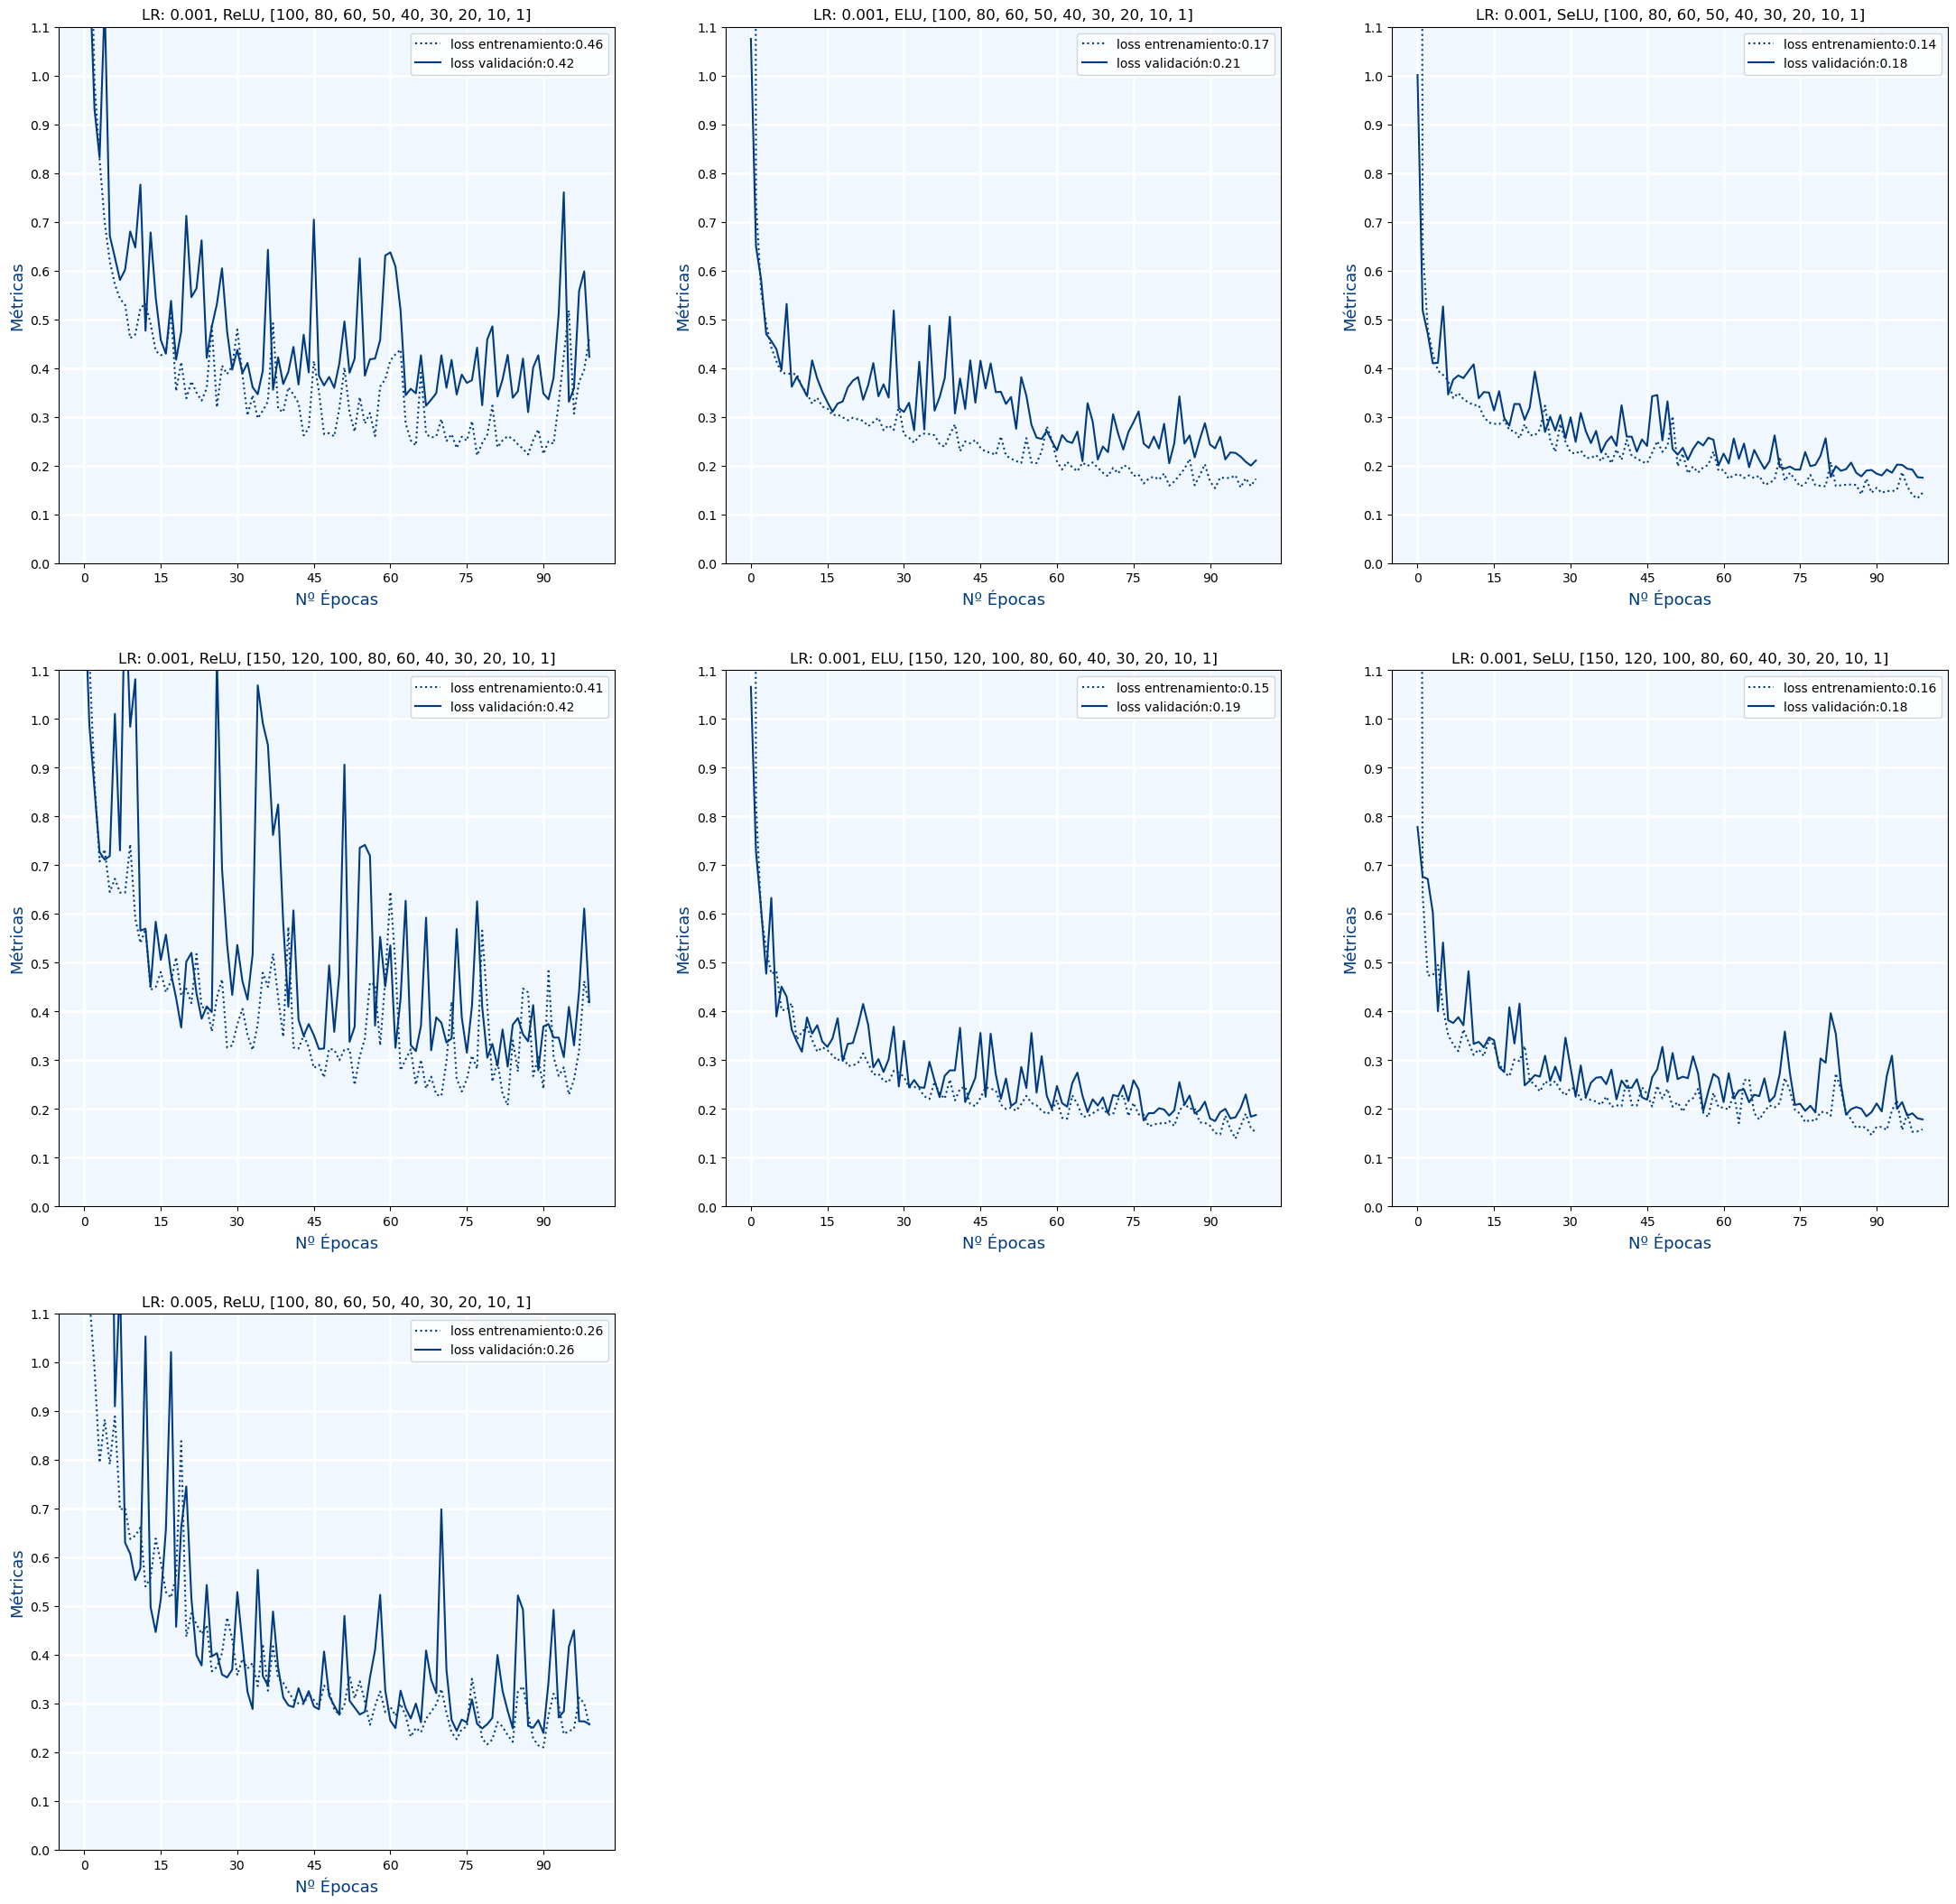

In [18]:
# Importamos las bibliotecas necesarias
import random
from matplotlib.ticker import MaxNLocator, MultipleLocator
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

def plot_metrics(axes,history,title):

    axes.plot(history['loss'],linestyle="dotted",label=f"loss entrenamiento:{history['loss'][-1]:.2f}",c="#003B80")  
    axes.plot(history['val_loss'],linestyle="solid",label=f"loss validación:{history['val_loss'][-1]:.2f}",c="#003B80")

    axes.set_xlabel('Nº Épocas', fontsize=13,color="#003B80") 
    axes.xaxis.set_major_locator(MaxNLocator(integer=True))

    axes.set_ylabel('Métricas', fontsize=13,color="#003B80")
    axes.set_ylim(ymin=0,ymax=1.1)
    axes.yaxis.set_major_locator(MultipleLocator(0.1))

    axes.set_title(title)
    axes.set_facecolor("#F0F7FF")
    axes.grid(visible=True, which='major', axis='both',color="#FFFFFF",linewidth=2)
    axes.legend()

def compile_fit(capas,activation,last_activation,loss,epochs,x_train, x_test, y_train, y_test, lr):

    input_dim=x_train.shape[1]

    np.random.seed(5)
    tf.random.set_seed(5)
    random.seed(5)
    
    model=Sequential()
    
    for index,neuronas_capa in enumerate(capas):
        if (index==0):
            model.add(Dense(neuronas_capa, activation=activation,input_dim=input_dim))
        elif (index==len(capas)-1):
            model.add(Dense(neuronas_capa, activation=last_activation))          
        else:
            model.add(Dense(neuronas_capa, activation=activation))

    opt = keras.optimizers.Adam(learning_rate=lr)

    model.compile(loss=loss, optimizer=opt)
    
    history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=epochs,verbose=True) 

    return history,model


# 3. Estandarizamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


epochs=100

redes_capas=[
    [100, 80, 60, 50, 40, 30, 20, 10, 1], # 7 capas ocultas, 100 neuronas en la primera capa, 80 en la segunda, 60 en la tercera, 50 en la cuarta, 40 en la quinta, 30 en la sexta, 20 en la séptima, 10 en la octava, 1 neurona de salida
    [150, 120, 100, 80, 60, 40, 30, 20, 10, 1], # 8 capas ocultas, 150 neuronas en la primera capa, 120 en la segunda, 100 en la tercera, 80 en la cuarta, 60 en la quinta, 40 en la sexta, 30 en la séptima, 20 en la octava, 10 en la novena, 1 neurona de salida
]
activations=[
        ("ReLU","relu"),
        ("ELU","elu"),
        ("SeLU","selu")]

learning_rates=[0.001,0.005,0.01]

# Configurar la figura con el número correcto de filas y columnas
rows = len(learning_rates) * len(redes_capas)
cols = len(activations)
figure = plt.figure(figsize=(9 * cols, 9 * rows))  # Ajustar tamaño según filas y columnas

index = 1

for learning_rate in learning_rates:
    for capas in redes_capas:
        for caption, activation in activations:
            history, model = compile_fit(capas, activation, "linear", "mean_absolute_error", epochs, X_train_scaled, X_test_scaled, y_train, y_test, lr=learning_rate)
            axes = figure.add_subplot(rows, cols, index)  # Usar rows y cols corregidos
            plot_metrics(axes, history.history, f"LR: {learning_rate}, {caption}, {str(capas)}")
            index += 1

figure.tight_layout()
plt.show()